<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Finding Missing Values**


Estimated time needed: **30** minutes


Data wrangling is the process of cleaning, transforming, and organizing data to make it suitable for analysis. Finding and handling missing values is a crucial step in this process to ensure data accuracy and completeness. In this lab, you will focus exclusively on identifying and handling missing values in the dataset.


## Objectives


After completing this lab, you will be able to:


-   Identify missing values in the dataset.

- Quantify missing values for specific columns.

- Impute missing values using various strategies.


## Hands on Lab


##### Setup: Install Required Libraries


In [9]:
!pip install pandas
!pip install matplotlib
!pip install seaborn

##### Import Necessary Modules:


In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Tasks


<h2>1. Load the Dataset</h2>
<p>
We use the <code>pandas.read_csv()</code> function for reading CSV files. However, in this version of the lab, which operates on JupyterLite, the dataset needs to be downloaded to the interface using the provided code below.
</p>


The functions below will download the dataset into your browser:



In [11]:
# Define the URL of the dataset
file_path ="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/UDKAZw-kz18Yj8P6icf_qw/survey-data-duplicates.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

### 2. Explore the Dataset
##### Task 1: Display basic information and summary statistics of the dataset.


In [12]:
## Write your code here

#Displays all the columns
pd.set_option("display.max_rows", None)

#number of rows and columns
df.shape

#column names, data types and non null count
df.info()

#stats of numeric columns
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 65447 entries, 0 to 65446
Columns: 114 entries, ResponseId to JobSat
dtypes: float64(13), int64(1), str(100)
memory usage: 195.7 MB

,ResponseId,CompTotal,WorkExp,JobSatPoints_1,JobSatPoints_4,JobSatPoints_5,JobSatPoints_6,JobSatPoints_7,JobSatPoints_8,JobSatPoints_9,JobSatPoints_10,JobSatPoints_11,ConvertedCompYearly,JobSat
count,65447.000000,3.374000e+04,29659.000000,29325.000000,29394.000000,29412.000000,29451.000000,29449.000000,29457.000000,29457.000000,29451.000000,29446.000000,2.343500e+04,29126.000000
mean,32714.001528,2.963841e+145,11.467143,18.580460,7.521884,10.060515,24.342405,22.964440,20.277477,16.168883,10.955341,9.953610,8.615529e+04,6.935041
std,18893.063225,5.444117e+147,9.168610,25.966005,18.422399,21.833543,27.089272,27.017612,26.107934,24.844789,22.905963,21.775359,1.867570e+05,2.088259
min,1.000000,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000e+00,0.000000
25%,16352.500000,6.000000e+04,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.271200e+04,6.000000
50%,32714.000000,1.100000e+05,9.000000,10.000000,0.000000,0.000000,20.000000,15.000000,10.000000,5.000000,0.000000,0.000000,6.500000e+04,7.000000
75%,49075.500000,2.500000e+05,16.000000,22.000000,5.000000,10.000000,30.000000,30.000000,25.000000,20.000000,10.000000,10.000000,1.079715e+05,8.000000
max,65437.000000,1.000000e+150,50.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,100.000000,1.625660e+07,10.000000


### 3. Finding Missing Values
##### Task 2: Identify missing values for all columns.


In [13]:
#check missing values in each column and sort them is ascending order
df.isnull().sum().sort_values()

ResponseId                            0
MainBranch                            0
Age                                   0
Employment                            0
Check                                 0
AISelect                           4530
EdLevel                            4653
LearnCode                          4949
NEWSOSites                         5151
YearsCode                          5569
LanguageHaveWorkedWith             5693
SOAccount                          5878
SOVisitFreq                        5902
DevType                            5993
SOComm                             6275
SOHow                              6476
Country                            6507
OpSysPersonal use                  7265
NEWCollabToolsHaveWorkedWith       7847
SurveyEase                         9201
SurveyLength                       9257
LanguageWantToWorkWith             9686
OfficeStackSyncHaveWorkedWith      9894
RemoteWork                        10635
CodingActivities                  10975


##### Task 3: Visualize missing values using a heatmap (Using seaborn library).



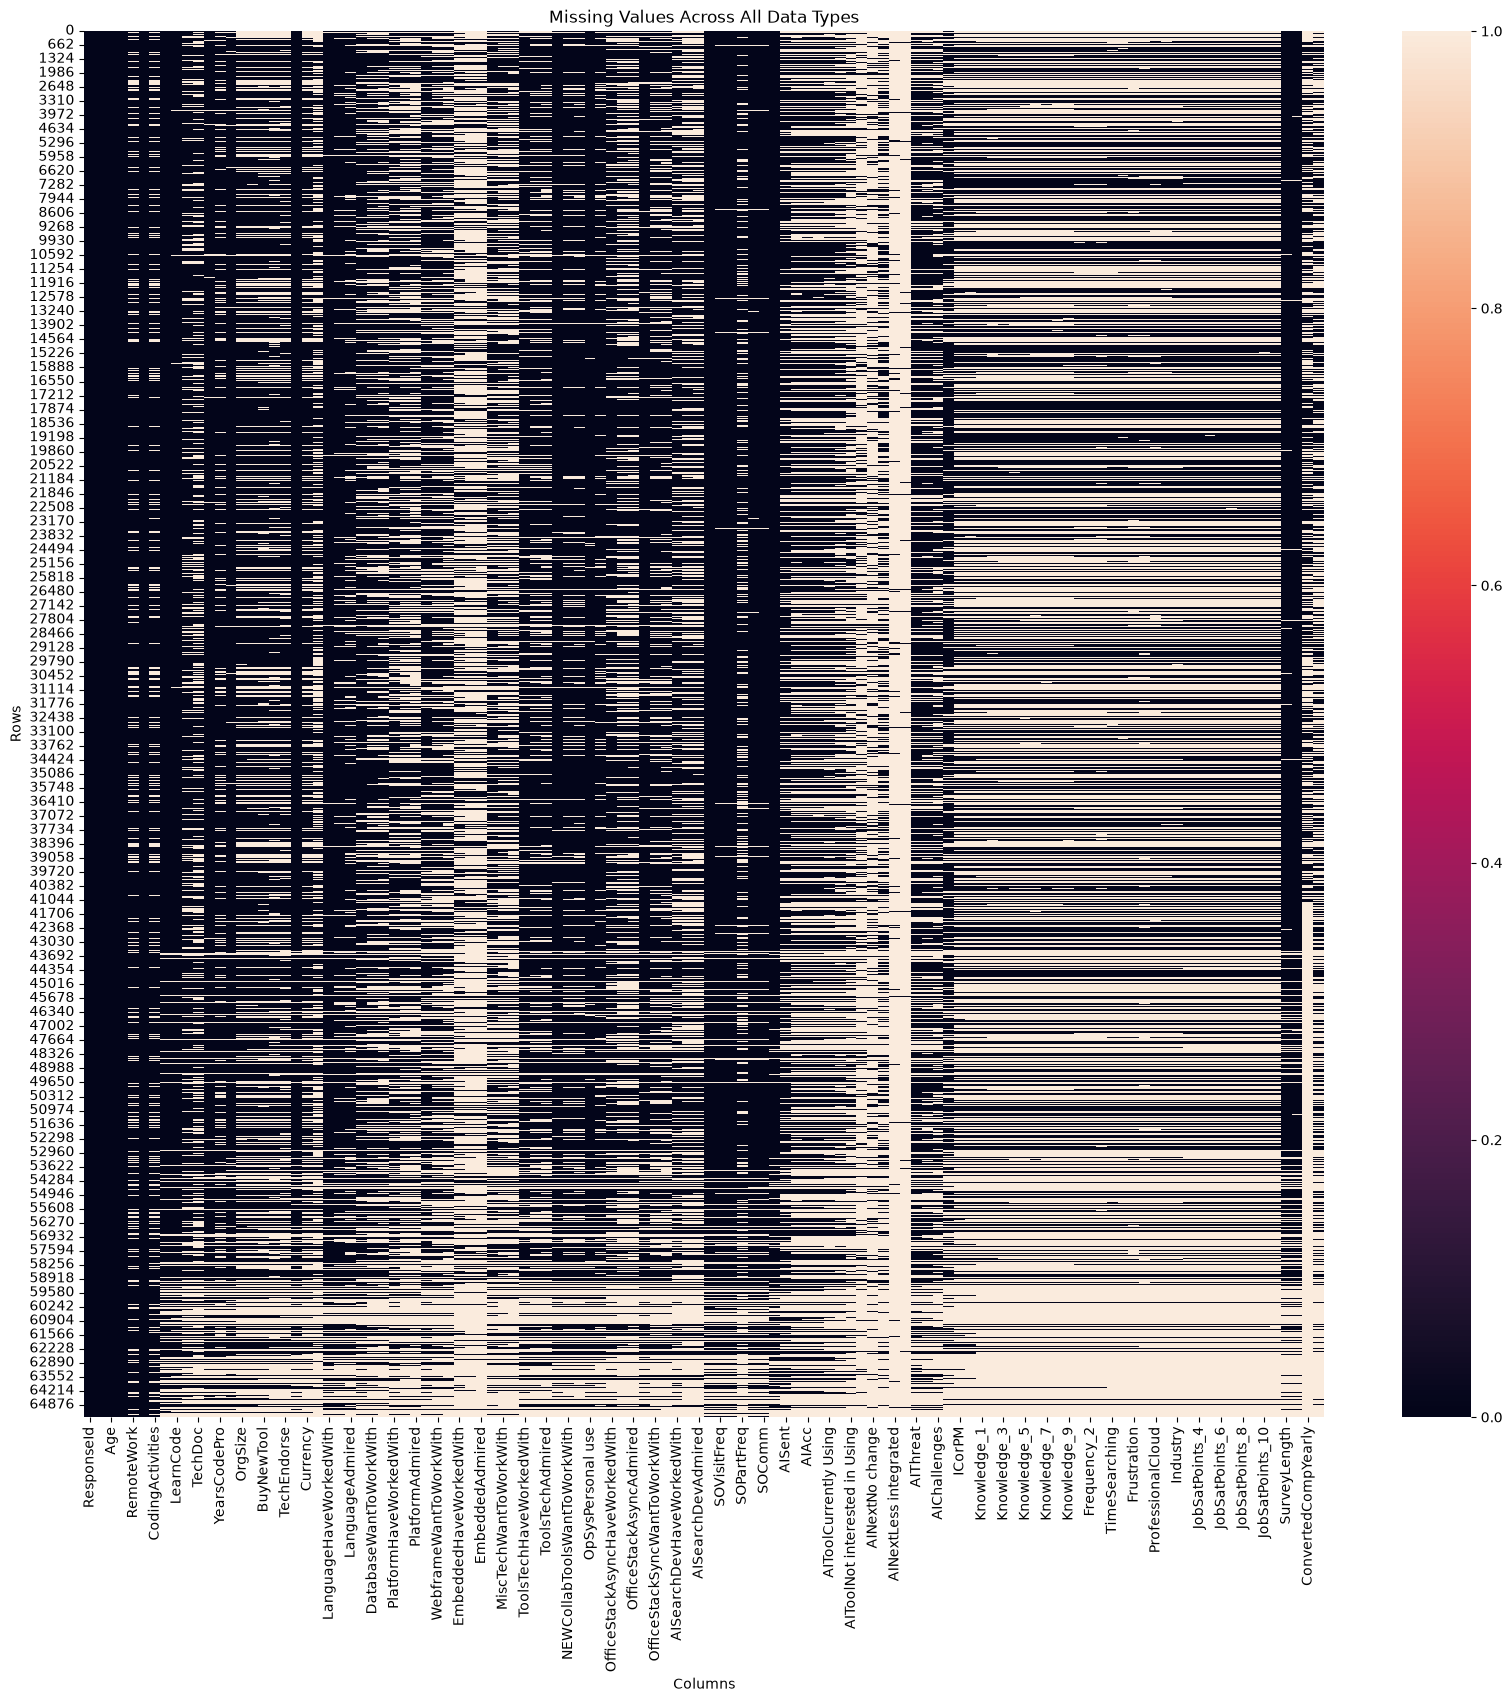

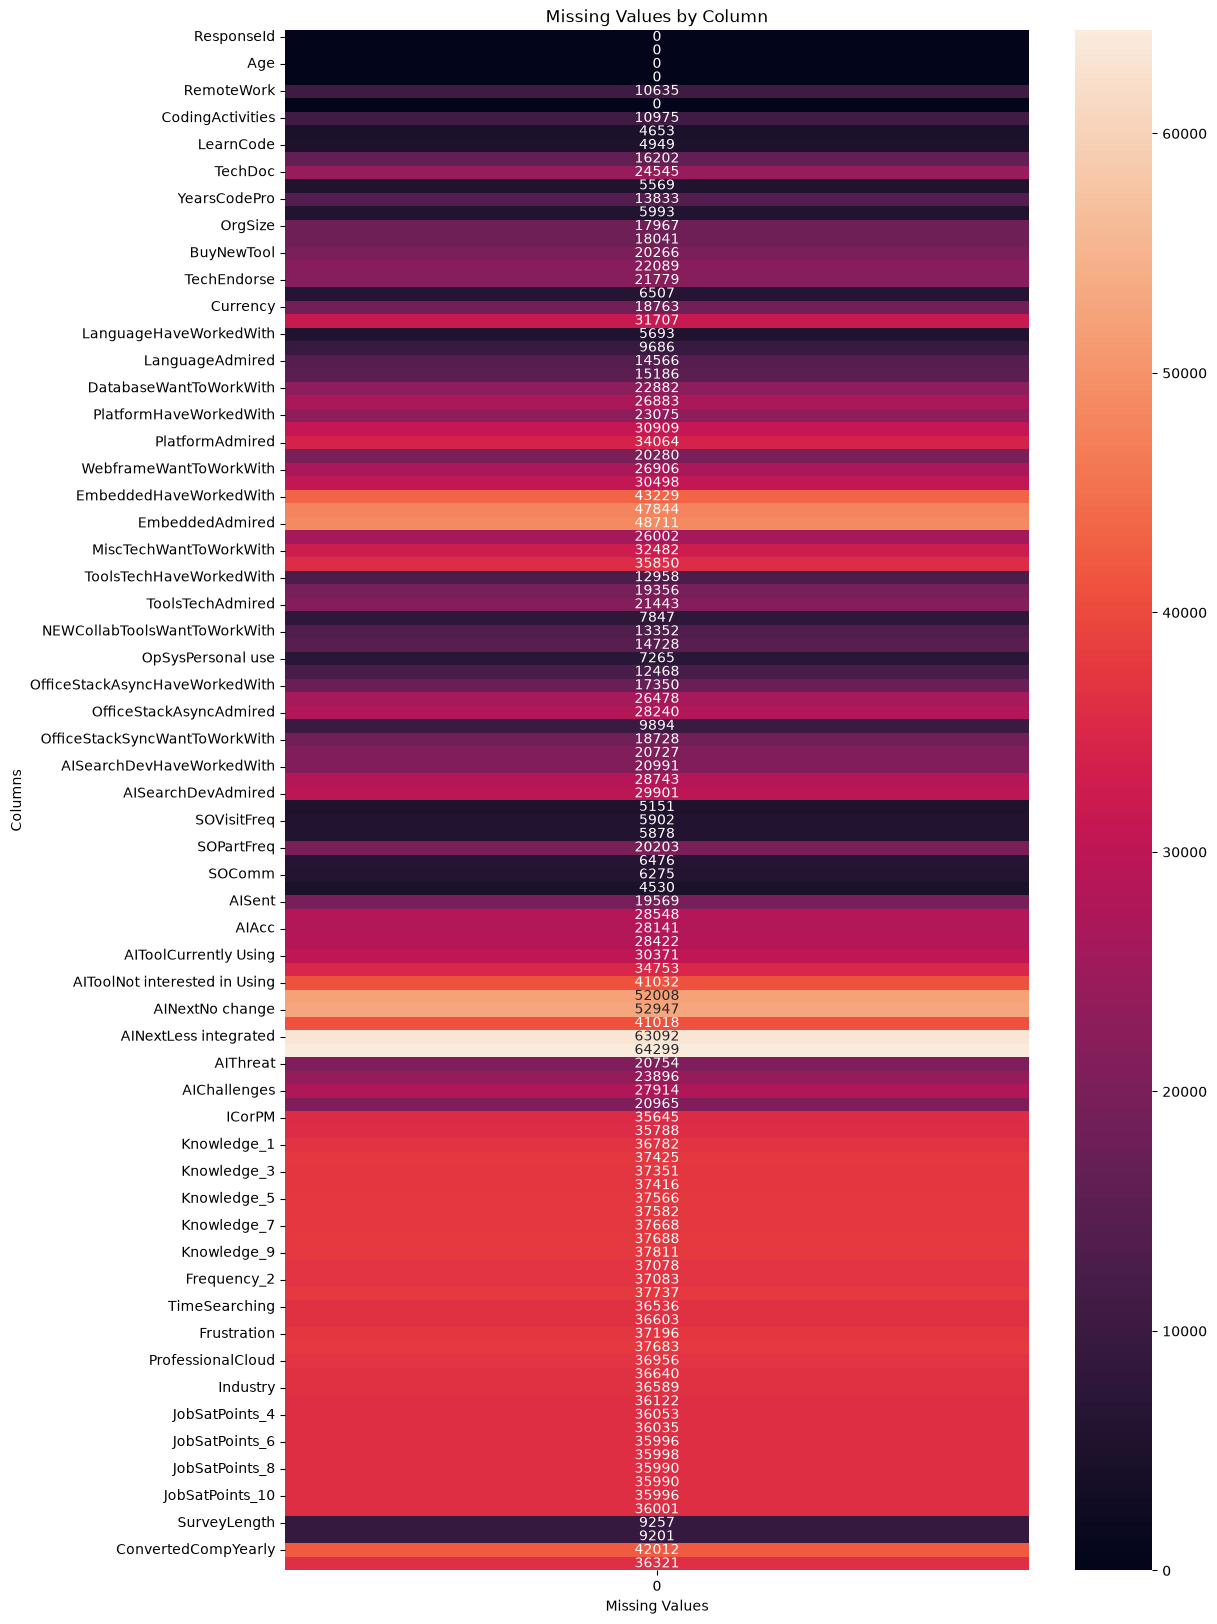

In [34]:
## Write your code here

plt.figure(figsize=(20, 18))

sns.heatmap(df.isnull())
plt.title("Missing Values Across All Data Types")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

#second heatmap option

plt.figure(figsize=(12, 20))

null_counts = df.isnull().sum().to_frame()

sns.heatmap(
    null_counts,
    annot=True,
    fmt="g"
)

plt.title("Missing Values by Column")
plt.xlabel("Missing Values")
plt.ylabel("Columns")
plt.show()

##### Task 4: Count the number of missing rows for a specific column (e.g., `Employment`).


In [36]:
## Write your code here

print("Number of missing values for Employment column is", df["Employment"].isnull().sum())

Number of missing values for Employment column is 0

### 4. Imputing Missing Values
##### Task 5: Identify the most frequent (majority) value in a specific column (e.g., `Employment`).


In [42]:
## Write your code here

print("The majority value for Employment column is", df["Employment"].mode()[0], 
      "& it appears",
      df["Employment"].value_counts().iloc[0],
      "times"
     )

The majority value for Employment column is Employed, full-time & it appears 39046 times

##### 

Task 6: Impute missing values in the `Employment` column with the most frequent value.



In [46]:
## Write your code here

# Create a copy of df that I can make changes to
df_clean = df.copy()

#The most common Employment
Most_Employment = df_clean["Employment"].mode()[0]

#Impute nulls with the most frequent Employment

df_clean["Employment"] = df_clean["Employment"].fillna(Most_Employment)
print(df_clean["Employment"].head())

#Count the nulls in the clean df to confirm NO changes have been made because there no missing values

print("Number of missing values for Employment column is still", df_clean["Employment"].isnull().sum())

0    Employed, full-time
1    Employed, full-time
2    Employed, full-time
3     Student, full-time
4     Student, full-time
Name: Employment, dtype: str
Number of missing values for Employment column is still 0

### 5. Visualizing Imputed Data
##### Task 7: Visualize the distribution of a column after imputation (e.g., `Employment`).


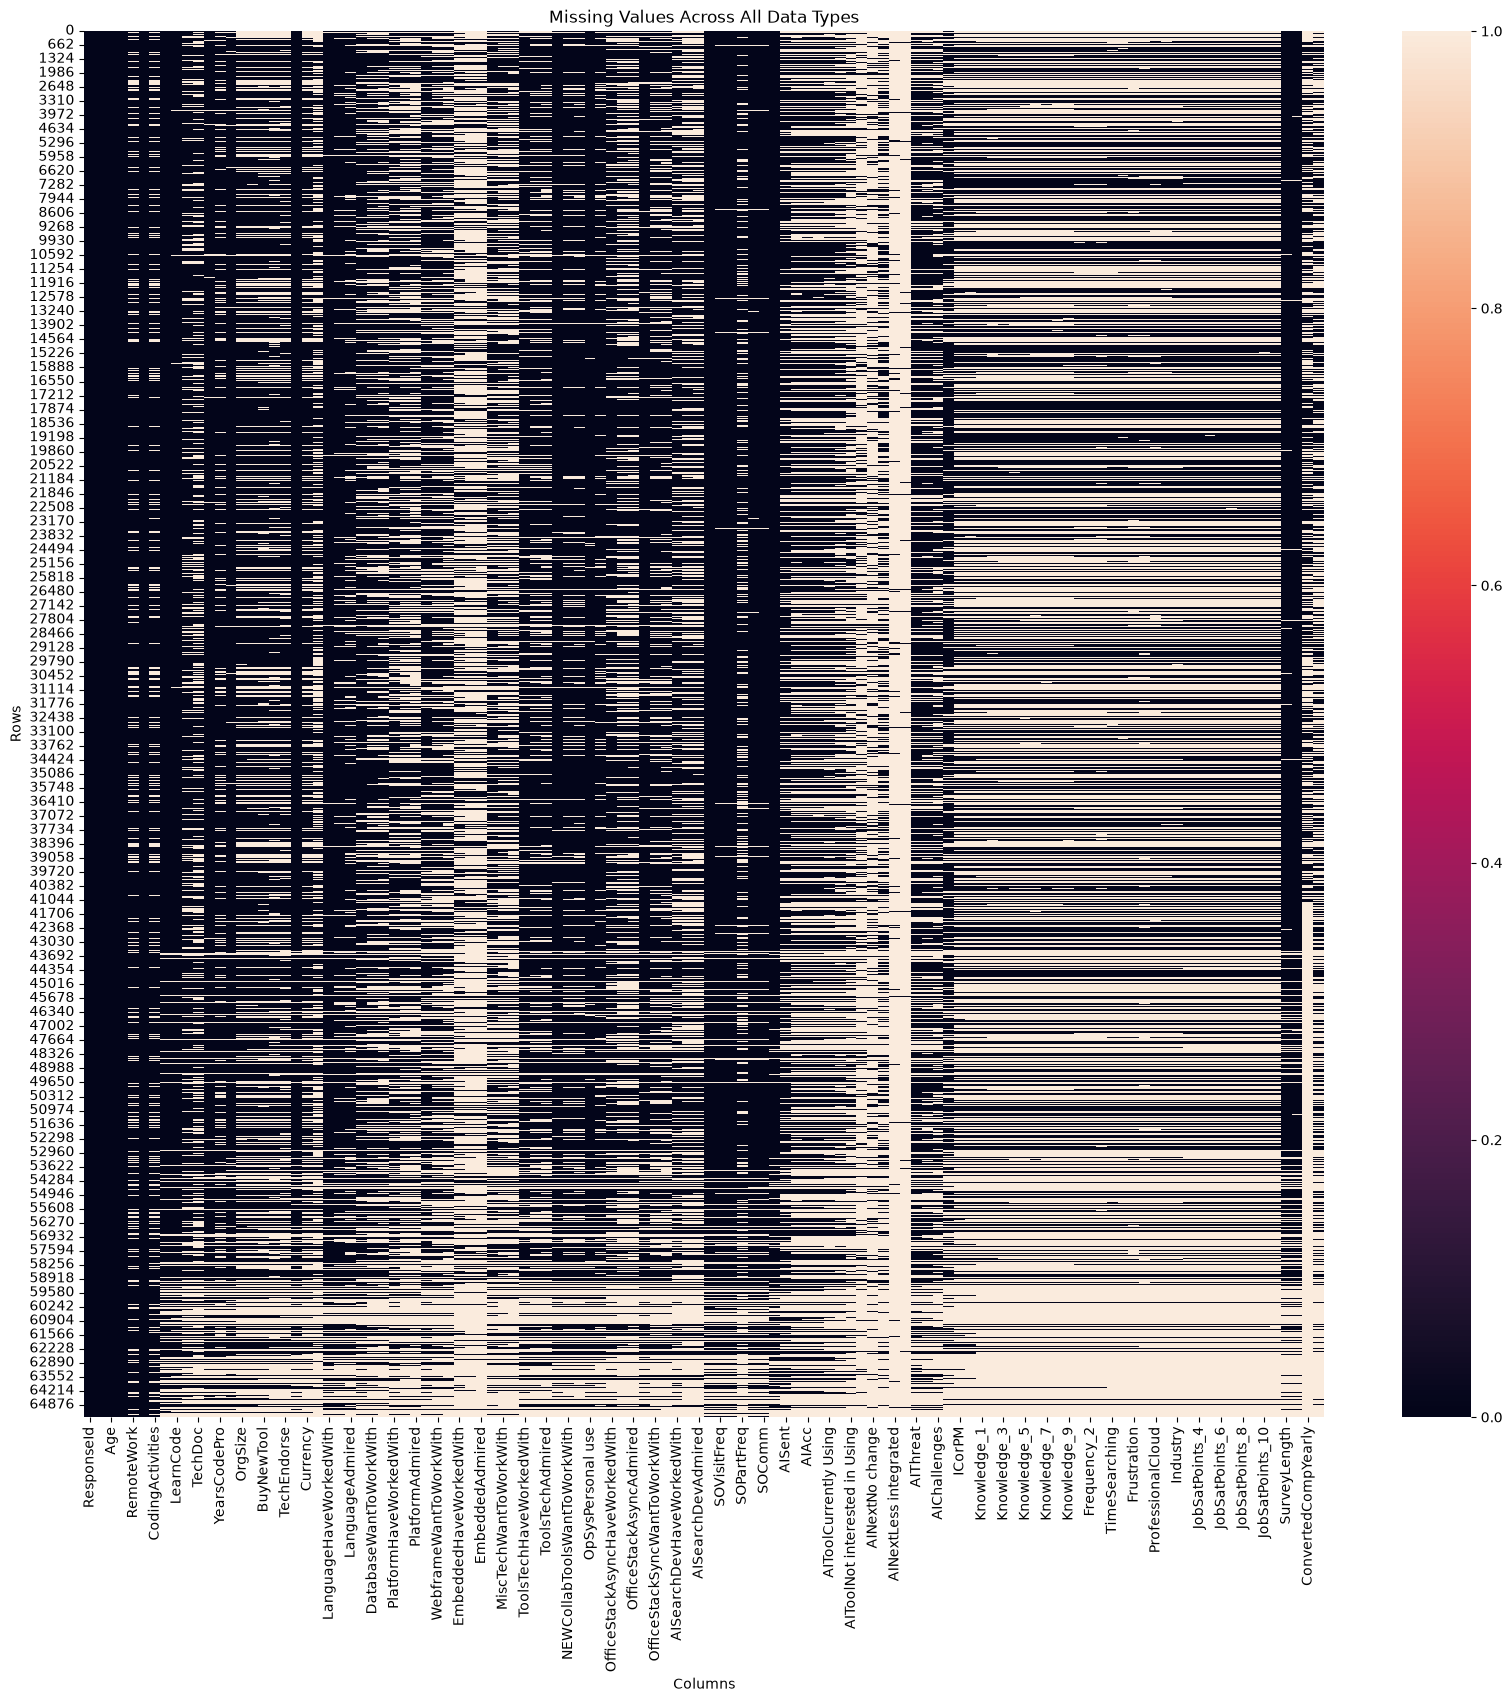

In [45]:
## Write your code here

plt.figure(figsize=(20, 18))

sns.heatmap(df_clean.isnull())
plt.title("Missing Values Across All Data Types")
plt.xlabel("Columns")
plt.ylabel("Rows")
plt.show()

### Summary


In this lab, you:
- Loaded the dataset into a pandas DataFrame.
- Identified missing values across all columns.
- Quantified missing values in specific columns.
- Imputed missing values in a categorical column using the most frequent value.
- Visualized the imputed data for better understanding.
  


Copyright © IBM Corporation. All rights reserved.
